<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/SVM_na_base_de_dados_do_Titanic_Aprendizado_de_Maquina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Usando SVM na base de dados do Titanic

Aprendizado de Máquina 26.1

**Aluno:** Matheus Ramos Ferreira da Silva

In [58]:
import pandas as pd

url = "https://raw.githubusercontent.com/Matheus0820/Aprendizado-de-Maquina/refs/heads/main/unidade01/datasets/titanic_dataset/train.csv"

df = pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Selecionando colunas que irão entrar na classificação

### Entradas ($X$)
- Pclass
- Sex
- age
- SibSp
- Fare

### Saída ($y$)
- Survived

In [59]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']].values

X[:5]

array([[3, 'male', 22.0, 1, 7.25],
       [1, 'female', 38.0, 1, 71.2833],
       [3, 'female', 26.0, 0, 7.925],
       [1, 'female', 35.0, 1, 53.1],
       [3, 'male', 35.0, 0, 8.05]], dtype=object)

In [60]:
y = df['Survived'].values
y = y.reshape(-1, 1)

y[:5]

array([[0],
       [1],
       [1],
       [1],
       [0]])

## Tratando dados
- Transformando valores em string em valores numericos.
- Transformar Sex de "male" e "female" para 0 e 1, respectivamente
- Verificar se há valores NAN, se tiver tornar eles igual a 0

In [61]:
# Tornando na coluna Sex: male = 0 e female = 1
X[:, 1] = [0 if x == 'male' else 1 for x in X[:, 1]]

# Procurando se há valores NaN e tornando eles igual a zero
for i in range(X.shape[1]):
  for j in range(X.shape[0]):
    if pd.isna(X[j, i]):
      X[j, i] = 0

X[:5]



array([[3, 0, 22.0, 1, 7.25],
       [1, 1, 38.0, 1, 71.2833],
       [3, 1, 26.0, 0, 7.925],
       [1, 1, 35.0, 1, 53.1],
       [3, 0, 35.0, 0, 8.05]], dtype=object)

## Divisão dos dados - Treino e teste

In [62]:
from sklearn.model_selection import train_test_split
import time
time_random = time.time()
time_random = int(time_random)

# Separando nos valores para teste e para treino
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=time_random)

# Tamanho dos conjuntos de dados
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (712, 5)
X_test: (179, 5)
y_train: (712, 1)
y_test: (179, 1)


## Normalização dos dados
Manter a variação dos dados entre 0 e 1 para ter resultados mais coerêntes

In [63]:
# Importando biblioteca responsável por isso
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Valores de X após a normalização")
print(f"X_train:\n {X_train[:5]}", end="\n\n")
print(f"X_test:\n {X_test[:5]}")

Valores de X após a normalização
X_train:
 [[0.         1.         0.3625     0.         0.41250333]
 [1.         0.         0.25       0.         0.01411046]
 [1.         0.         0.2375     0.         0.01541158]
 [0.5        0.         0.         0.         0.        ]
 [1.         0.         0.2        0.5        0.07746484]]

X_test:
 [[0.         0.         0.225      0.125      0.21255864]
 [1.         0.         0.7375     0.         0.01415106]
 [0.         0.         0.8875     0.         0.09662576]
 [0.5        0.         0.2875     0.         0.02537431]
 [1.         1.         0.35       0.125      0.02810693]]


## Treinamento da SVM

In [64]:
# Importanto biblioteca
from sklearn.svm import SVC

# Criando o classificador com o karnel linear
classifier = SVC(kernel='linear', random_state=0)

# Treinando o classificador
classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', random_state=0)

## Avaliando o Modelo

In [65]:
# importando a biblioteca de metricas do sklearn
from sklearn.metrics import accuracy_score, confusion_matrix

# Pegando valores de y atraves do modelo treinado
y_pred = classifier.predict(X_test)

# Acurácia - Vendo se os valores obtidos atráves do modelo batem com os reais
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy}")

# Calculando a matriz de confusão
confusion_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(confusion_matrix)

Acurácia: 0.7597765363128491
Matriz de confusão:
[[93 21]
 [22 43]]


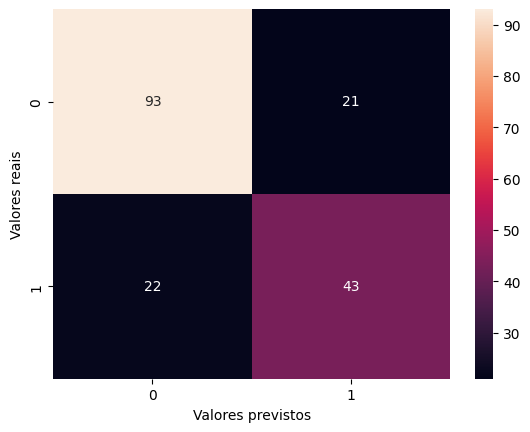

In [66]:
# Mostrando a matriz de confusão de forma gráfica
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix, annot=True, fmt='d')
plt.xlabel('Valores previstos')
plt.ylabel('Valores reais')
plt.show()